In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error

In [22]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/casos_dengue_2020-2025.csv"
df = pd.read_csv(ruta)
df.head()

,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,QUINTANA ROO,SAN LUIS POTOSI,SINALOA,SONORA,TABASCO,TAMAULIPAS,TLAXCALA,VERACRUZ,YUCATAN,ZACATECAS
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,106,47,40,8,112,111,0,249,58,3
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,167,74,46,13,158,206,0,441,62,0
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,158,80,48,12,166,190,0,412,73,2
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,130,53,54,13,167,191,1,418,54,1
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,99,43,48,9,139,173,1,322,45,1


In [23]:
df.columns

Index(['FECHA', 'AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR',
       'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA',
       'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO',
       'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON',
       'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI',
       'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ',
       'YUCATAN', 'ZACATECAS'],
      dtype='object')

In [24]:
cols_municipios = ['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR',
       'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA',
       'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO',
       'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON',
       'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI',
       'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ',
       'YUCATAN', 'ZACATECAS']

In [25]:
df["FECHA"] = pd.to_datetime(df["FECHA"])

df["casos_semana"] = df[cols_municipios].sum(axis=1)

df[["FECHA", "casos_semana"]]

,FECHA,casos_semana
0,2020-01-05,1318
1,2020-01-12,2068
2,2020-01-19,2078
3,2020-01-26,1973
4,2020-02-02,1562
...,...,...
277,2025-04-27,1504
278,2025-05-04,1549
279,2025-05-11,1878
280,2025-05-18,1932


In [26]:
df["FECHA"] = pd.to_datetime(df["FECHA"])

df["casos_semana"] = df[cols_municipios].sum(axis=1)

df[["FECHA", "casos_semana"]]

,FECHA,casos_semana
0,2020-01-05,1318
1,2020-01-12,2068
2,2020-01-19,2078
3,2020-01-26,1973
4,2020-02-02,1562
...,...,...
277,2025-04-27,1504
278,2025-05-04,1549
279,2025-05-11,1878
280,2025-05-18,1932


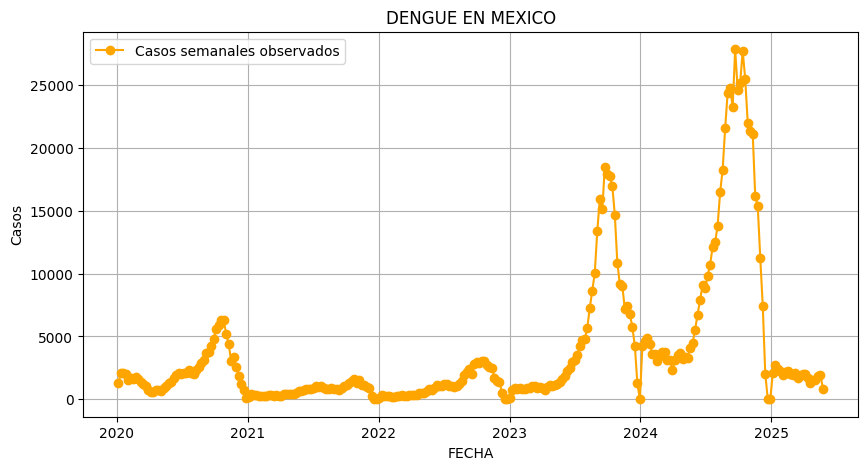

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["FECHA"],
    df["casos_semana"],
    marker="o",
    label="Casos semanales observados",
    color='orange'
)

plt.xlabel("FECHA")
plt.ylabel("Casos")
plt.title("DENGUE EN MEXICO")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

¿Se observan picos de casos?
se observan 3 picos en el año 2020,2023 y 2024, sin encambio por el mes de octubre del 2023 y octubre del 2024 se notan los mayores picos

¿En qué periodos parecen concentrarse los aumentos?
 por el mes agostos a octubre mas o menos

¿La serie parece estable o variable?por momento hay una estabilidad pero en cierto momentos aumenta por facotres externos


¿Se observa algún posible patrón estacional?
vizualmente por que en algunos años no hay picos pero en otros si el unico patro que podemos observar es en el ultimos dos años

¿Qué dificultades podría tener un modelo para predecir esta serie? que no tenemos factores externos los cuales pueden modificar el modelo

In [28]:
df["lag_1"] = df["casos_semana"].shift(1) # Rezagos
df["lag_2"] = df["casos_semana"].shift(2)
df["lag_3"] = df["casos_semana"].shift(3)

df["promedio_movil_3"] = df["casos_semana"].rolling(window=3).mean() # Promedios móviles
df["promedio_movil_5"] = df["casos_semana"].rolling(window=5).mean()

df["cambio_semanal"] = df["casos_semana"].diff() # Cambio semanal

df["casos_siguiente_semana"] = df["casos_semana"].shift(-1) # Variable objetivo

df.head()

,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,YUCATAN,ZACATECAS,casos_semana,lag_1,lag_2,lag_3,promedio_movil_3,promedio_movil_5,cambio_semanal,casos_siguiente_semana
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,58,3,1318,NaN,NaN,NaN,NaN,NaN,NaN,2068.0
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,62,0,2068,1318.0,NaN,NaN,NaN,NaN,750.0,2078.0
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,73,2,2078,2068.0,1318.0,NaN,1821.333333,NaN,10.0,1973.0
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,54,1,1973,2078.0,2068.0,1318.0,2039.666667,NaN,-105.0,1562.0
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,45,1,1562,1973.0,2078.0,2068.0,1871.000000,1799.8,-411.0,1659.0


In [29]:
columnas_modelo = [
    "FECHA",
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "casos_siguiente_semana"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.head()

,FECHA,casos_semana,lag_1,lag_2,lag_3,promedio_movil_3,promedio_movil_5,cambio_semanal,casos_siguiente_semana
0,2020-02-02,1562,1973.0,2078.0,2068.0,1871.000000,1799.8,-411.0,1659.0
1,2020-02-09,1659,1562.0,1973.0,2078.0,1731.333333,1868.0,97.0,1593.0
2,2020-02-16,1593,1659.0,1562.0,1973.0,1604.666667,1773.0,-66.0,1756.0
3,2020-02-23,1756,1593.0,1659.0,1562.0,1669.333333,1708.6,163.0,1598.0
4,2020-03-01,1598,1756.0,1593.0,1659.0,1649.000000,1633.6,-158.0,1384.0


In [30]:
variables_predictoras = [
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal"
]

X = df_modelo[variables_predictoras]
y = df_modelo["casos_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana   lag_1   lag_2   lag_3  promedio_movil_3  promedio_movil_5  \
0          1562  1973.0  2078.0  2068.0       1871.000000            1799.8   
1          1659  1562.0  1973.0  2078.0       1731.333333            1868.0   
2          1593  1659.0  1562.0  1973.0       1604.666667            1773.0   
3          1756  1593.0  1659.0  1562.0       1669.333333            1708.6   
4          1598  1756.0  1593.0  1659.0       1649.000000            1633.6   

   cambio_semanal  
0          -411.0  
1            97.0  
2           -66.0  
3           163.0  
4          -158.0  
0    1659.0
1    1593.0
2    1756.0
3    1598.0
4    1384.0
Name: casos_siguiente_semana, dtype: float64


In [31]:
variables_predictoras = [
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal"
]

X = df_modelo[variables_predictoras]
y = df_modelo["casos_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana   lag_1   lag_2   lag_3  promedio_movil_3  promedio_movil_5  \
0          1562  1973.0  2078.0  2068.0       1871.000000            1799.8   
1          1659  1562.0  1973.0  2078.0       1731.333333            1868.0   
2          1593  1659.0  1562.0  1973.0       1604.666667            1773.0   
3          1756  1593.0  1659.0  1562.0       1669.333333            1708.6   
4          1598  1756.0  1593.0  1659.0       1649.000000            1633.6   

   cambio_semanal  
0          -411.0  
1            97.0  
2           -66.0  
3           163.0  
4          -158.0  
0    1659.0
1    1593.0
2    1756.0
3    1598.0
4    1384.0
Name: casos_siguiente_semana, dtype: float64


In [32]:
n = len(df_modelo)

n_train = int(0.7 * n)

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["casos_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["casos_siguiente_semana"]

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (193, 7)
Tamaño prueba: (84, 7)


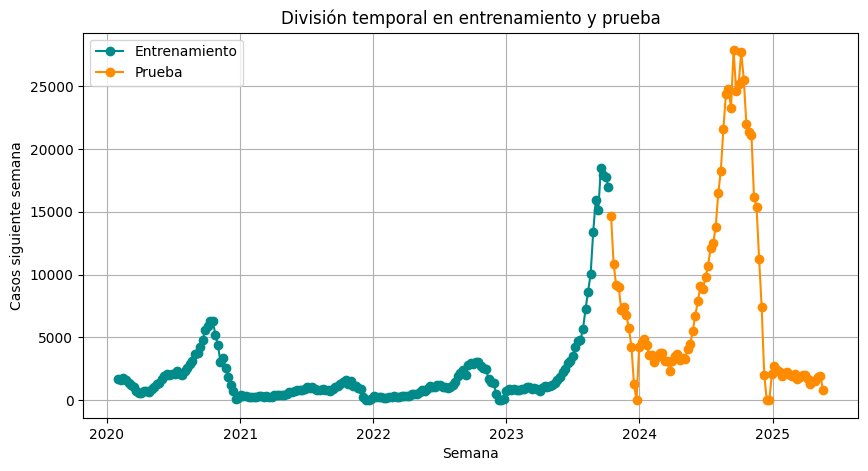

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_train["FECHA"],
    df_train["casos_siguiente_semana"],
    marker="o",
    label="Entrenamiento",
    color="darkcyan"
)

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    marker="o",
    label="Prueba",
    color="darkorange"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("División temporal en entrenamiento y prueba")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

Al tener datos anteriores esto nos pueden ayudar a predecir de mejor manera la prediccion, etso se debe a que puede guiar de manera secuencial lo que esta pasando.

In [34]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    return mae, rmse

In [35]:
df_test["pred_naive"] = df_test["casos_semana"]

mae_naive, rmse_naive = calcular_metricas(
    y_test,
    df_test["pred_naive"]
)

print("Modelo ingenuo")
print("MAE:", mae_naive)
print("RMSE:", rmse_naive)

Modelo ingenuo
MAE: 1163.3690476190477
RMSE: 1751.9682434880137


In [36]:
modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

# Evitar predicciones negativas
pred_lr = np.maximum(pred_lr, 0)

mae_lr, rmse_lr = calcular_metricas(y_test, pred_lr)

print("Regresión lineal")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Regresión lineal
MAE: 1025.1621233636238
RMSE: 1430.1695059892522


In [37]:
modelo_arbol = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

pred_arbol = np.maximum(pred_arbol, 0)

mae_arbol, rmse_arbol = calcular_metricas(y_test, pred_arbol)

print("Árbol de decisión")
print("MAE:", mae_arbol)
print("RMSE:", rmse_arbol)

Árbol de decisión
MAE: 2142.5192080021798
RMSE: 3415.513044504592


In [38]:
modelo_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

pred_rf = np.maximum(pred_rf, 0)

mae_rf, rmse_rf = calcular_metricas(y_test, pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
MAE: 2627.4712491342043
RMSE: 4078.9068111337065


In [39]:
df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Regresión lineal",
        "Árbol de decisión",
        "Random Forest"
    ],
    "MAE": [
        mae_naive,
        mae_lr,
        mae_arbol,
        mae_rf
    ],
    "RMSE": [
        rmse_naive,
        rmse_lr,
        rmse_arbol,
        rmse_rf
    ]
})

df_metricas.sort_values("RMSE")

,modelo,MAE,RMSE
1,Regresión lineal,1025.162123,1430.169506
0,Naive,1163.369048,1751.968243
2,Árbol de decisión,2142.519208,3415.513045
3,Random Forest,2627.471249,4078.906811


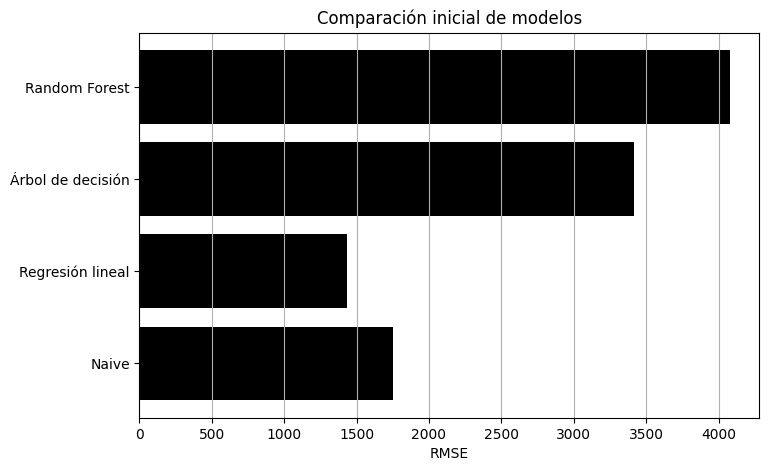

In [40]:
plt.figure(figsize=(8, 5))

plt.barh(
    df_metricas["modelo"],
    df_metricas["RMSE"], color='black'
)

plt.xlabel("RMSE")
plt.title("Comparación inicial de modelos")
plt.grid(axis="x")

plt.show()

In [41]:

df_test["pred_lr"] = pred_lr
df_test["pred_arbol"] = pred_arbol
df_test["pred_rf"] = pred_rf

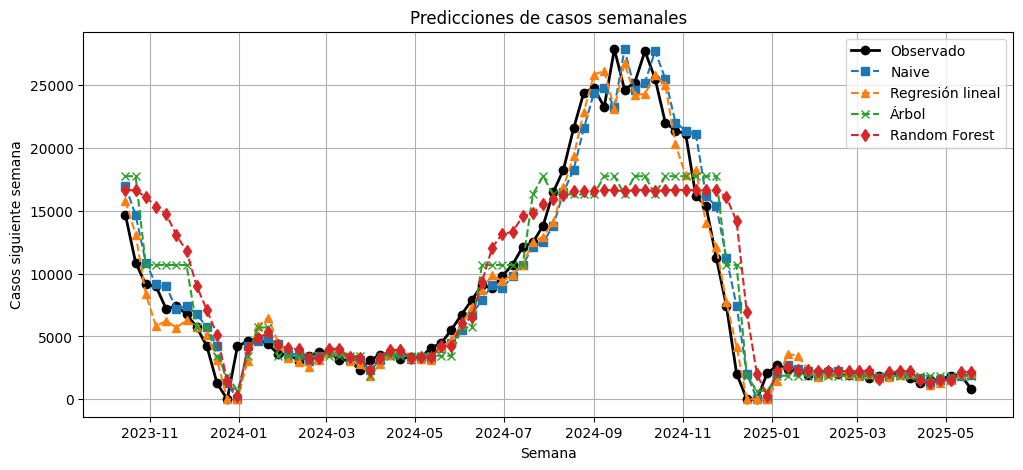

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["FECHA"],
    df_test["casos_siguiente_semana"],
    marker="o",
    label="Observado", color = 'black', lw=2
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_naive"],
    marker="s",
    linestyle="--",
    label="Naive"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_lr"],
    marker="^",
    linestyle="--",
    label="Regresión lineal"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_arbol"],
    marker="x",
    linestyle="--",
    label="Árbol"
)

plt.plot(
    df_test["FECHA"],
    df_test["pred_rf"],
    marker="d",
    linestyle="--",
    label="Random Forest"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("Predicciones de casos semanales")
plt.legend()
plt.grid()

plt.show()

¿Qué modelo tuvo menor MAE?
el modelo que tiene MAE es la de regresion lineal con 2050.324247

¿Qué modelo tuvo menor RMSE?
de igual manera en el modelo RMSE el que tuvo menor valor es regresion lineal con 2860.339012

¿El modelo más complejo fue necesariamente el mejor?
en este caso no ya que el modelo de regresion lineal dio mejor resultado que el resto

¿Algún modelo logró mejorar al modelo ingenuo?
en este caso no

¿Qué modelo parece capturar mejor los picos?
el modelo Naives es e que se puede vizualisar de manera mejor los picos aun qu regresion lineal igual se ajusta bien.


¿En qué periodos se observan los mayores errores?

# ***PARTE4***